# Predicción de Churn en Comercializadora de Telecomunicaciones

## Introducción

### El problema de negocio

El churn es la tasa que mide el porcentaje de clientes que abandonan una compañía 
en un periodo determinado. En el sector de las comercializadoras de telecomunicaciones, 
donde la oferta está altamente commoditizada y el coste de cambio para el cliente 
es bajo, la retención es una palanca crítica de rentabilidad.

Retener a un cliente existente es significativamente más barato que captar uno nuevo. 
Por ello, anticiparse al abandono permite al equipo comercial actuar con antelación: 
contactar al cliente en riesgo con una oferta personalizada antes de que tome la 
decisión de irse.

### Objetivo del proyecto

El objetivo es construir un modelo predictivo que estime la probabilidad de que un 
cliente abandone la compañía en el próximo periodo. El modelo no produce una respuesta 
determinista (se va / no se va), sino una probabilidad entre 0 y 1 que permite 
priorizar los clientes de mayor riesgo y orientar la acción comercial.

El usuario final es el equipo de retención, que recibirá una lista ordenada por 
probabilidad de churn para actuar sobre los casos más críticos.

### Dataset

Se utiliza el dataset Telco Customer Churn de IBM, compuesto por 7.043 registros 
de clientes con información sobre su contrato, servicios contratados, facturación 
y comportamiento de una comercializadora de telecomunicaciones. Su estructura es 
directamente extrapolable a otros sectores con modelos de suscripción similares, 
como el energético: contratos de duración variable, facturación mensual, servicios 
adicionales y una variable objetivo binaria de abandono, lo que lo convierte en 
un proxy válido para prototipado en ausencia de datos propietarios.

### Enfoque técnico

Se trata de un problema de clasificación binaria supervisada. Dado que los errores 
no tienen el mismo coste (no detectar un cliente que se va es más caro que 
contactar innecesariamente a uno que se quedaba) se priorizarán métricas como 
Recall y AUC-ROC sobre accuracy, que resultaría engañosa dado el desbalanceo 
moderado de la variable objetivo.

## Limpieza de los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telecom.csv')

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.shape

(7043, 21)

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Estructura general
print(df.shape)
print(df.dtypes)

# Variable objetivo
print(df["Churn"].value_counts(normalize=True) * 100)

# Valores nulos
print(df.isnull().sum())

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
Stream

Podemos observar que nuestro dataset tiene 7043 filas y 21 columnas, y ningun elemento faltante. El 73% de nuestros datos tienen como resultado de la variable objetivo "no churn", con un 27% restante "churn", por tanto, se podría decir que tenemos un dataset desbalanceado, lo que es normal en este tipo de problemas. 

Además, la variable 'TotalCharges' debería de estar como 'int' y esta como 'string'.

In [11]:
# Detectamos los valores que no se pueden convertir a numéricos
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()

print(df[mask]['TotalCharges'].value_counts())
print(df[mask])

TotalCharges
    11
Name: count, dtype: int64
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone serv

Hay 11 valores que no se están transformando bien, vamos a ver cuales son.

In [14]:
# Ver que valores son los que no se pueden convertir a numéricos
print(df[mask][["tenure","MonthlyCharges", "TotalCharges","Churn"]])

      tenure  MonthlyCharges TotalCharges Churn
488        0           52.55                 No
753        0           20.25                 No
936        0           80.85                 No
1082       0           25.75                 No
1340       0           56.05                 No
3331       0           19.85                 No
3826       0           25.35                 No
4380       0           20.00                 No
5218       0           19.70                 No
6670       0           73.35                 No
6754       0           61.90                 No


Vemos que son clientes que no han llegado a tener ningún mes de facturación, por lo que pandas lo está detectando como un string vacío. La mejor solución es eliminar estas filas de nuestro modelo puesto que son muy pocos datos comparados con todos los que tenemos en el dataset. También haré algunos ajustes a otras variables para limpiar los datos.

In [15]:
# 1. Eliminar filas problemáticas
df = df[df["tenure"] != 0].copy()

# 2. Convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# 3. Eliminar customerID
df = df.drop(columns=["customerID"])

# 4. Convertir variable objetivo a binaria
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(df.shape)
print(df.dtypes)

(7032, 20)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


Uno de los factores que tenemos que tener en cuenta es la multicolinealidad de nuestros datos. Las variables 'tenure', 'MonthlyCharges', 'TotalCharges' es muy probable que vayan a estar altamente correlacionadas entre sí ya que dependen entre sí una de la otra.

                                TotalCharges = tenure x MonthlyCharges

Para elegir cual borrar hay que tener en cuenta la idea de negocio. ¿Cuál es la variable que es más facilmente explicable a un directivo de negocio? Esta claro que la variable de tenure se tiene que quedar, ya que es facilmente interpretable (Alguien que lleva 2 meses todavía no esta afianzado en la compañía y puede ser más probable a darse de baja).

Las variables 'tenure' y 'Monthly_charges' son independientes entre sí, ya que un cliente puede llevar mucho tiempo, pagar poco y viceversa. Por eso vamos a omitir la variable Total_charges

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()
print(corr)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000      0.651065
TotalCharges    0.825880        0.651065      1.000000


Para demostralo empíricamente, vemos que la correlación de TotalCharges con las otras dos es > 0.7-0.8, por lo que la decisión queda respaldada por datos, no solo por lógica.

In [ ]:
# Eliminamos TotalCharges por su alta correlación
df = df.drop(columns=["TotalCharges"])

In [21]:
print(df.shape)
print(df.dtypes)

(7032, 19)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
Churn                 int64
dtype: object


In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1


## Análisis exploratorio de los datos

El objetivo de esta sección es contrastar las hipótesis que se sugerieron anteriormente.

- Contratos mensuales → mayor churn
- Clientes nuevos → mayor riesgo
- Facturas altas → mayor churn
- Muchas llamadas a soporte → mayor churn

### 1. Variable objetivo: Churn

Primeramente vamos a visualizar como se distribuye el churn en base a las diferentes variables que disponemos.

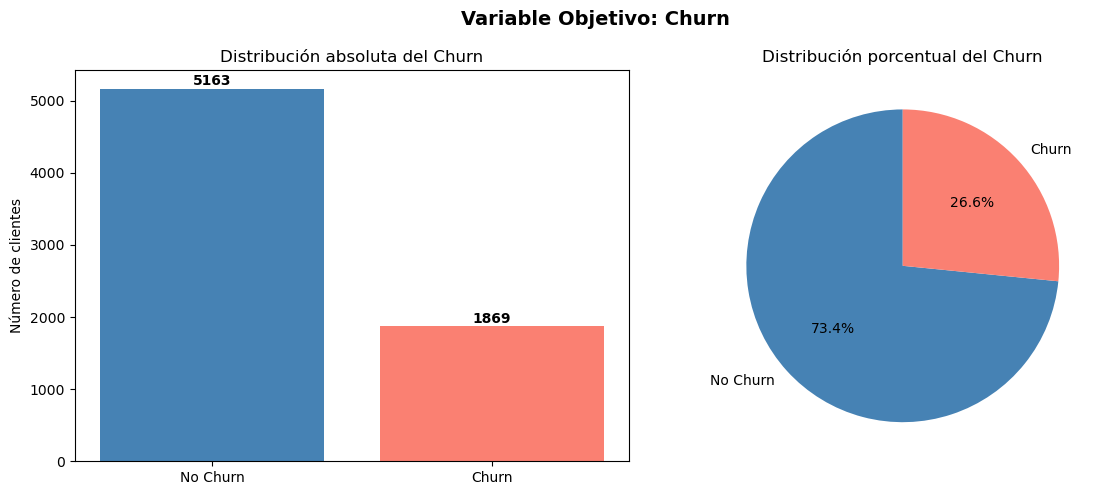

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras con conteo
churn_counts = df["Churn"].value_counts()
axes[0].bar(["No Churn", "Churn"], churn_counts.values, 
            color=["steelblue", "salmon"])
axes[0].set_title("Distribución absoluta del Churn")
axes[0].set_ylabel("Número de clientes")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# Gráfico de tarta con porcentajes
axes[1].pie(churn_counts.values, labels=["No Churn", "Churn"],
            autopct="%1.1f%%", colors=["steelblue", "salmon"],
            startangle=90)
axes[1].set_title("Distribución porcentual del Churn")

plt.suptitle("Variable Objetivo: Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

La distribución de la variable objetivo muestra un desbalanceo moderado: el 73.5% 
de los clientes no hace churn frente a un 26.5% que sí abandona la compañía. 

Este desbalanceo es esperado y habitual en problemas de churn — en el mundo real, 
la mayoría de clientes permanece. Un 27% de clase minoritaria no es un desbalanceo 
grave (casos extremos serían 95/5), por lo que no será necesario aplicar técnicas 
agresivas como SMOTE. Bastará con ajustar `class_weight='balanced'` en los modelos 
y priorizar métricas adecuadas como AUC-ROC y Recall sobre accuracy, que resultaría 
engañosa en este contexto.

### 2. Variables numéricas

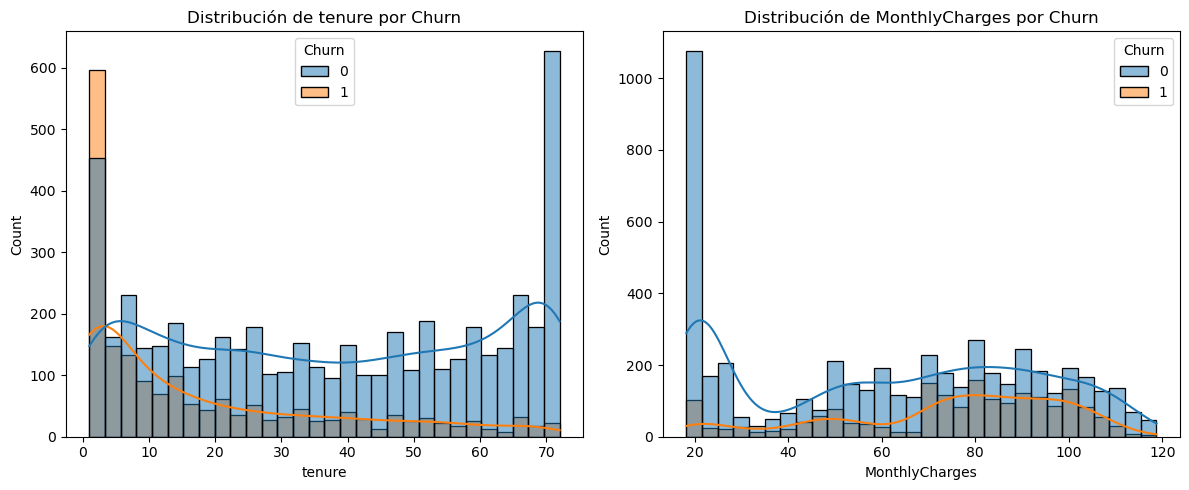

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", 
                 kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribución de {col} por Churn")

plt.tight_layout()
plt.show()

Vemos en la distribución de **tenure**, que los clientes que se dan de baja tienden a hacerlo más cuando llevan poco en la compañia y que a medida que van teniendo más cantidad de tenure el número de bajas va disminuyendo, estabilizandose en torno a los 20 meses. Los clientes que se quedan presentan una distribución más uniforme

En cuanto a la distribución de los **cargos mensuales**, los clientes con factura baja da lugar a que muy pocos se van. Tienen un servicio básico y barato, no tienen incentivo para buscar alternativas. El switching cost emocional supera el ahorro potencial.

Clientes con factura alta da proporcionalmente más churn. Pagan más, por tanto tienen más incentivo económico para comparar precios y cambiarse.

/tmp/ipykernel_700687/1158648154.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_700687/1158648154.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


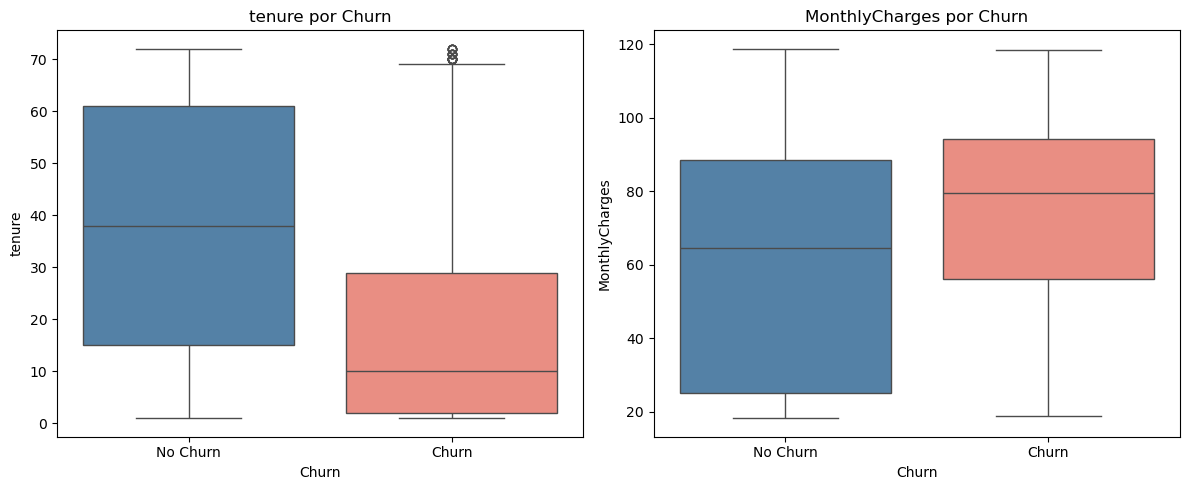

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_order = ["0", "1"]
churn_palette = {"0": "steelblue", "1": "salmon"}

for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    sns.boxplot(
        data=df,
        x="Churn",
        y=col,
        order=churn_order,
        palette=churn_palette,
        ax=ax,
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Churn", "Churn"])
    ax.set_title(f"{col} por Churn")

plt.tight_layout()
plt.show()

**Tenure:** Los clientes que abandonan presentan una mediana de permanencia 
significativamente menor que los que se quedan. El churn se concentra en los 
primeros meses de vida del cliente, estabilizándose a partir de los 20 meses 
aproximadamente. Esto confirma la hipótesis de que los clientes recientes son 
el segmento de mayor riesgo.

**MonthlyCharges:** Los clientes que hacen churn presentan facturas mensuales 
más altas que los que permanecen. Esto tiene sentido de negocio: a mayor factura, 
mayor incentivo económico para comparar ofertas y cambiarse de compañía.

Esto confirma la hipótesis de que facturas altas correlacionan con mayor churn.

## Variables Categóricas

Vamos a analizar como se comportan las variables categóricas, donde podremos indagar sobre hipótesis importantes como el tipo de cliente que en base a diferentes variables, tiende más a darse de baja.

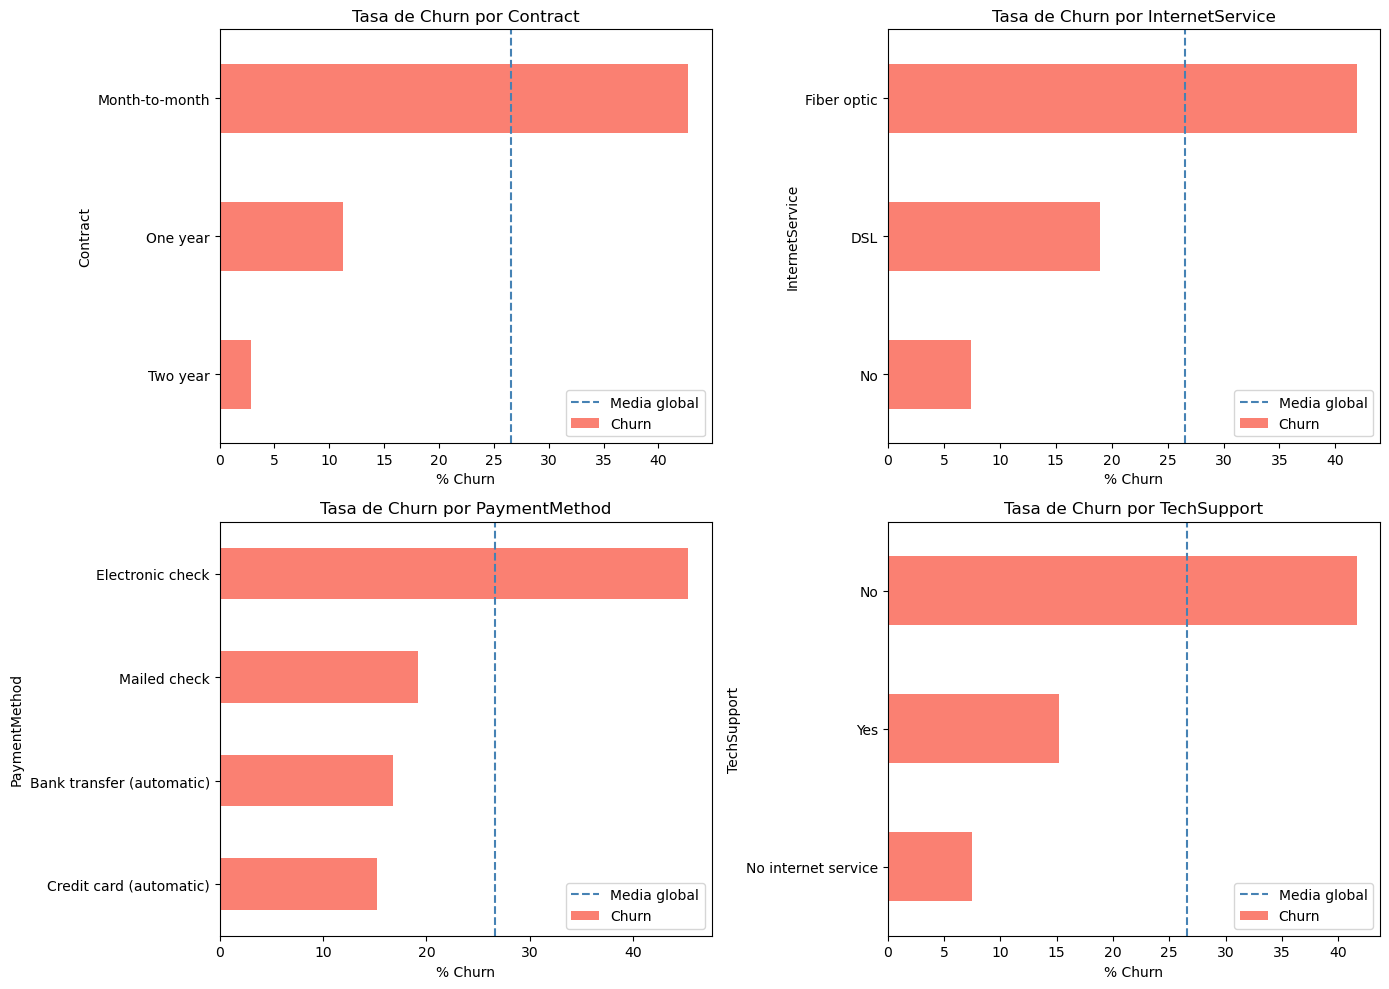

In [30]:
cat_cols = ["Contract", "InternetService", 
            "PaymentMethod", "TechSupport"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate = df.groupby(col)["Churn"].mean() * 100
    churn_rate.sort_values().plot(kind="barh", ax=ax,
                                   color="salmon")
    ax.set_title(f"Tasa de Churn por {col}")
    ax.set_xlabel("% Churn")
    ax.axvline(x=df["Churn"].mean() * 100, 
               color="steelblue", linestyle="--", 
               label="Media global")
    ax.legend()

plt.tight_layout()
plt.show()

**Tipo de contrato:** Es el diferenciador más claro. Los contratos mes a mes 
presentan una tasa de churn del ~43%, frente al ~11% anual y ~3% bianual. 
Los contratos mensuales generan más ventanas de decisión para el cliente, 
mientras que firmar un contrato largo es en sí mismo una señal de satisfacción 
previa con la compañía.

**Servicio de internet:** Los clientes con fibra óptica presentan mayor churn 
(~42%). Esto puede explicarse por dos factores: mayor precio mensual asociado 
(confirmando el patrón de MonthlyCharges) y mayor competencia en este segmento 
al ser el servicio más demandado del mercado.

**Método de pago:** Los pagos automáticos (tarjeta y transferencia) correlacionan 
con menor churn. El pago manual mediante cheque electrónico supera la media global 
con diferencia. Los clientes con pago automático tienen mayor fricción de salida 
y un perfil menos activo en la gestión de sus gastos.

**Soporte técnico:** Los clientes sin soporte técnico contratado presentan churn 
por encima de la media. Una posible palanca de retención sería facilitar el acceso 
al soporte técnico en segmentos de riesgo.

### Correlación con la variable objetivo

/tmp/ipykernel_700687/3776242170.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include="object").columns:


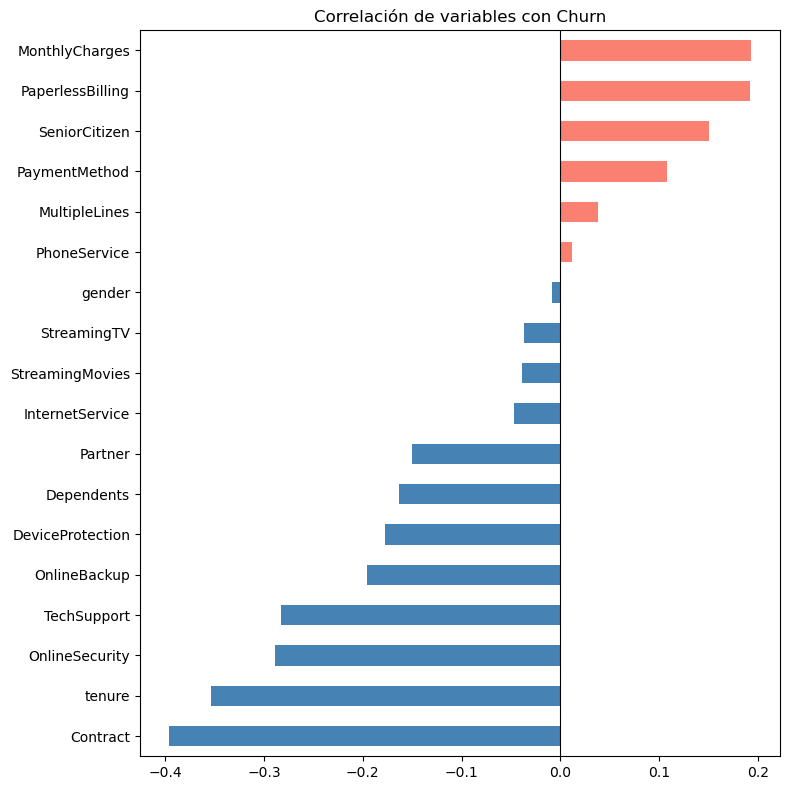

In [31]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Codificación temporal solo para correlación
df_corr = df.copy()
le = LabelEncoder()
for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = le.fit_transform(df_corr[col])

# Correlación de todas las variables con Churn
correlaciones = df_corr.corr()["Churn"].drop("Churn").sort_values()

plt.figure(figsize=(8, 8))
correlaciones.plot(kind="barh", color=[
    "salmon" if x > 0 else "steelblue" for x in correlaciones])
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Correlación de variables con Churn")
plt.tight_layout()
plt.show()

El análisis de correlación confirma y matiza las hipótesis previas. Las variables 
con mayor correlación negativa con Churn son Contract y tenure porque 
el LabelEncoder asigna valores más altos a contratos de mayor duración (Month-to-month 
→ 0, One year → 1, Two year → 2), por lo que a mayor valor de la variable codificada, 
menor churn. En términos de negocio, el tipo de contrato es el predictor más fuerte: 
los clientes con contrato mensual son el segmento de mayor riesgo.

Por el lado positivo, MonthlyCharges y PaperlessBilling son las variables más 
correlacionadas con el abandono. Los clientes con factura electrónica presentan 
un perfil más digital y comparador, con mayor propensión a evaluar ofertas de la 
competencia.

Con esto concluye el EDA. Las hipótesis de negocio formuladas antes de explorar 
los datos han sido confirmadas en su mayoría, y disponemos de un entendimiento 
sólido de los factores de riesgo para construir el modelo predictivo.